# News Article Classification (Fake / Real)

**Goal:** Build a model that reads a news article and says if it is Fake or Real.

**Tools:** Python, Pandas, NLTK, Scikit-learn

**Steps:**
1. Load the dataset
2. Clean the text
3. Convert text to numbers (TF-IDF)
4. Train a model
5. Check how good the model is
6. Save the model (to use later in the Streamlit app)


## Step 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import joblib

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

STOPWORDS = set(stopwords.words('english'))


## Step 2: Load the dataset

Go to Kaggle and download the **"Fake and Real News Dataset"** by Clement Bisaillon:
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

It gives you two files: `Fake.csv` and `True.csv`.
Put both files in the same folder as this notebook, then run the cell below.

In [2]:
fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

# Add a label column: 0 = fake, 1 = real
fake_df["label"] = 0
true_df["label"] = 1

# Combine both into one dataset
df = pd.concat([fake_df, true_df], axis=0)

# Shuffle the rows so fake and real are mixed, not in blocks
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total articles:", len(df))
print(df["label"].value_counts())
df.head()


Total articles: 44898
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [3]:
# Some versions of this dataset have separate 'title' and 'text' columns.
# We combine them into one column called 'content' so we use all the text.
if "title" in df.columns and "text" in df.columns:
    df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")
else:
    df["content"] = df["text"].fillna("")

df = df[["content", "label"]]
df.head()


,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


## Step 3: Clean the text

We remove links, punctuation, numbers, and common words like 'the', 'is', 'and' (stopwords).

In [4]:
def clean_text(text):
    text = text.lower()                                   # make lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)      # remove links
    text = re.sub(r'<.*?>', '', text)                      # remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)                        # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()               # remove extra spaces

    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in STOPWORDS]
    return " ".join(words)

df["clean_content"] = df["content"].apply(clean_text)
df[["content", "clean_content"]].head()


,content,clean_content
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein calls th circuit court committed ‘co...
1,Trump drops Steve Bannon from National Securit...,trump drops steve bannon national security cou...
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects us lift jones act shipping...
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...
4,Donald Trump heads for Scotland to reopen a go...,donald trump heads scotland reopen golf resort...


## Step 4: Convert text to numbers (TF-IDF)

A model can't read words directly, so we turn each article into a vector of numbers based on how important each word is.

In [5]:
X = df["clean_content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training samples:", X_train_tfidf.shape)
print("Test samples:", X_test_tfidf.shape)


Training samples: (35918, 5000)
Test samples: (8980, 5000)


## Step 5: Train the models

We train two simple models and compare them: Logistic Regression and Naive Bayes.

In [6]:
# Model 1: Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_tfidf, y_train)
log_preds = log_model.predict(X_test_tfidf)

# Model 2: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_preds = nb_model.predict(X_test_tfidf)


## Step 6: Check how good the models are

In [7]:
def show_scores(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:   ", round(recall_score(y_true, y_pred), 4))
    print("F1-score: ", round(f1_score(y_true, y_pred), 4))
    print()

show_scores("Logistic Regression", y_test, log_preds)
show_scores("Naive Bayes", y_test, nb_preds)


--- Logistic Regression ---
Accuracy:  0.9922
Precision: 0.9889
Recall:    0.9949
F1-score:  0.9919

--- Naive Bayes ---
Accuracy:  0.9519
Precision: 0.9465
Recall:    0.9531
F1-score:  0.9498



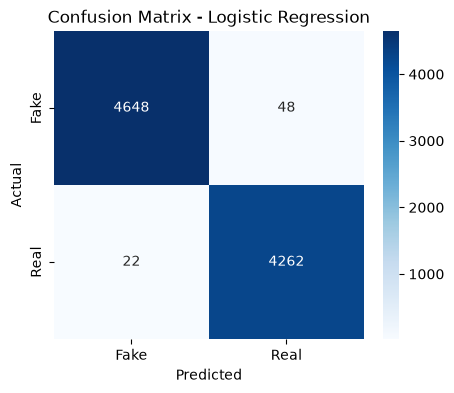

In [8]:
# Confusion matrix for Logistic Regression (whichever model performs best)
cm = confusion_matrix(y_test, log_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"], yticklabels=["Fake", "Real"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


**How to read these scores (good to know for interviews):**
- **Accuracy** = how many predictions were correct overall
- **Precision** = of the articles we said were "Real", how many actually were real
- **Recall** = of all the actual "Real" articles, how many did we correctly catch
- **F1-score** = a balance between precision and recall


## Step 7: Save the model

We save the trained model and the vectorizer so the Streamlit app can use them later.

In [9]:
# Pick whichever model scored better in Step 6 (commonly Logistic Regression)
joblib.dump(log_model, "news_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Saved: news_model.pkl and tfidf_vectorizer.pkl")


Saved: news_model.pkl and tfidf_vectorizer.pkl
